In [1]:
import numpy as np
from pymatgen.io.vasp import BSVasprun
from pymatgen.electronic_structure.core import Spin
import pandas as pd
import matplotlib.pyplot as plt, os


In [2]:
# --- CONFIG ---------------------------------------------------------------
strains = [-0.010, -0.005, -0.002, 0.000, +0.002, +0.005, +0.010]
NVAL = 4
DIR = {'hydro': './Hydrostatic_strain', 'uniaxial': './Uniaxial_strain', 'shear': './Shear'}
KP  = {'hydro': 'KPOINTS.line', 'uniaxial': 'KPOINTS.line', 'shear': 'KPOINTS.line'}

def load_bs(base, eps, kpfile):
    d = f"{base}/eps_{eps:+.4f}"
    return BSVasprun(f"{d}/vasprun.xml").get_band_structure(
        kpoints_filename=f"{d}/{kpfile}", line_mode=True)

def kidx(bs, frac, tol=2e-3):
    for i, k in enumerate(bs.kpoints):
        if np.allclose(k.frac_coords, frac, atol=tol):
            return i
    raise ValueError(f"k-point {frac} not on path")

# Each extractor now RETURNS (x_data, y_data, slope) so the plot can reuse them.
def extract_a():
    tr, eg = [], []
    for e in strains:
        bs = load_bs(DIR['hydro'], e, KP['hydro'])
        gap = bs.get_cbm()['energy'] - bs.get_vbm()['energy']
        tr.append(3*e); eg.append(gap)
        print(f"  eps={e:+.4f}  Tr={3*e:+.4f}  Eg={gap:.4f} eV")
    tr, eg = np.array(tr), np.array(eg)
    return tr, eg, np.polyfit(tr, eg, 1)[0]

def extract_Xiu():
    x, ds = [], []
    for e in strains:
        bs = load_bs(DIR['uniaxial'], e, KP['uniaxial'])
        cb = bs.bands[Spin.up][NVAL]
        g  = kidx(bs, (0.0, 0.0, 0.0))
        Ec_par, Ec_perp = cb[:g+1].min(), cb[g:].min()
        x.append(e); ds.append(Ec_par - Ec_perp)
        print(f"  eps={e:+.4f}  Ec_par={Ec_par:.4f}  Ec_perp={Ec_perp:.4f}  split={Ec_par-Ec_perp:+.4f}")
    x, ds = np.array(x), np.array(ds)
    return x, ds, np.polyfit(x, ds, 1)[0]

def extract_d():
    x, spr = [], []
    for e in strains:
        bs = load_bs(DIR['shear'], e, KP['shear'])
        g  = kidx(bs, (0.0, 0.0, 0.0))
        ev = bs.bands[Spin.up][NVAL-3:NVAL, g]
        x.append(abs(e)); spr.append(ev.max() - ev.min())
        print(f"  eps={e:+.4f}  Gamma25'={np.round(ev,4)}  spread={ev.max()-ev.min():.4f}")
    x, spr = np.array(x), np.array(spr)
    slope = np.polyfit(x, spr, 1)[0]
    return x, spr, slope / (3*np.sqrt(3))   # third element is |d|, not the raw slope

print("== hydrostatic =="); tr,  Eg,  a   = extract_a()
print("== uniaxial   =="); eu,  su,  Xiu = extract_Xiu()
print("== [111] shear =="); es,  sp,  d   = extract_d()

B = 98.0
dEg_dP = -a / B * 1000
print("\n================ deformation potentials ================")
print(f"  a = ac+av          = {a:+.3f} eV      (gap hydrostatic; expect a>0 for Si)")
print(f"  Xi_u (conduction)  = {Xiu:+.3f} eV      (lit. Si 9.0 +/- 2)")
print(f"  |d| (valence shear)= {abs(d):.3f} eV      (lit. Si ~5.3, d<0)")
print(f"  dEg/dP = -a/B      = {dEg_dP:+.2f} meV/GPa (expect ~ -15; expt cross-check)")


# creating a dataframe for usage in future 
from results_io import save_results
save_results(
    {"a": a, "Xi_u": Xiu, "|d|": abs(d),"eu": eu, "su": su, "dEg/dP": dEg_dP, "strains": strains},
    unit={"a": "eV", "Xi_u": "eV", "|d|": "eV", "dEg/dP": "eV/GPa", "strains":" "},
    source="DPT.ipynb",
)


== hydrostatic ==
  eps=-0.0100  Tr=-0.0300  Eg=0.5169 eV
  eps=-0.0050  Tr=-0.0150  Eg=0.5451 eV
  eps=-0.0020  Tr=-0.0060  Eg=0.5621 eV
  eps=+0.0000  Tr=+0.0000  Eg=0.5731 eV
  eps=+0.0020  Tr=+0.0060  Eg=0.5841 eV
  eps=+0.0050  Tr=+0.0150  Eg=0.6004 eV
  eps=+0.0100  Tr=+0.0300  Eg=0.6264 eV
== uniaxial   ==
  eps=-0.0100  Ec_par=6.4294  Ec_perp=6.5195  split=-0.0901
  eps=-0.0050  Ec_par=6.4174  Ec_perp=6.4622  split=-0.0448
  eps=-0.0020  Ec_par=6.4103  Ec_perp=6.4282  split=-0.0179
  eps=+0.0000  Ec_par=6.4056  Ec_perp=6.4056  split=+0.0000
  eps=+0.0020  Ec_par=6.4010  Ec_perp=6.3832  split=+0.0178
  eps=+0.0050  Ec_par=6.3940  Ec_perp=6.3498  split=+0.0442
  eps=+0.0100  Ec_par=6.3823  Ec_perp=6.2946  split=+0.0877
== [111] shear ==
  eps=-0.0100  Gamma25'=[5.7449 5.7449 6.024 ]  spread=0.2791
  eps=-0.0050  Gamma25'=[5.787  5.787  5.9276]  spread=0.1406
  eps=-0.0020  Gamma25'=[5.8138 5.8138 5.8704]  spread=0.0566
  eps=+0.0000  Gamma25'=[5.8325 5.8325 5.8325]  spread=0.0000

,quantity,value,unit,source
0,a,1.828811,eV,DPT.ipynb
1,Xi_u,8.893023,eV,DPT.ipynb
2,|d|,5.462859,eV,DPT.ipynb
3,eu,"[-0.01, -0.005, -0.002, 0.0, 0.002, 0.005, 0.01]",NaN,DPT.ipynb
4,su,"[-0.09009999999999962, -0.044800000000000395, ...",NaN,DPT.ipynb
5,dEg/dP,-18.661341,eV/GPa,DPT.ipynb
6,strains,"[-0.01, -0.005, -0.002, 0.0, 0.002, 0.005, 0.01]",,DPT.ipynb


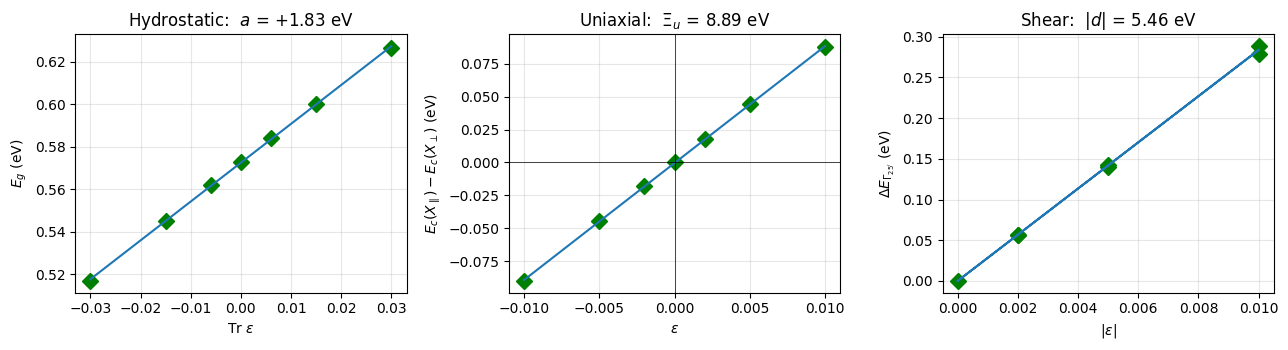

In [3]:
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

# Hydrostatic: slope = a
ax[0].plot(tr, Eg, 'D', color='green', markersize=8, label='DFT')
ax[0].plot(tr, np.polyval(np.polyfit(tr, Eg, 1), tr), '-')
ax[0].set(title=f"Hydrostatic:  $a$ = {a:+.2f} eV", xlabel=r"Tr $\varepsilon$", ylabel="$E_g$ (eV)")

# Uniaxial: slope = Xi_u  (note origin-crossing)
ax[1].plot(eu, su, 'D', color='green', markersize=8, label='DFT')
ax[1].plot(eu, np.polyval(np.polyfit(eu, su, 1), eu), '-')
ax[1].axhline(0, color='k', lw=0.5); ax[1].axvline(0, color='k', lw=0.5)
ax[1].set(title=f"Uniaxial:  $\\Xi_u$ = {Xiu:.2f} eV", xlabel=r"$\varepsilon$",
          ylabel=r"$E_c(X_\parallel)-E_c(X_\perp)$ (eV)")

# Shear: slope/(3 sqrt3) = |d|
ax[2].plot(es, sp, 'D', color='green', markersize=8, label='DFT')
ax[2].plot(es, np.polyval(np.polyfit(es, sp, 1), es), '-')
ax[2].set(title=f"Shear:  $|d|$ = {d:.2f} eV", xlabel=r"$|\varepsilon|$",
          ylabel=r"$\Delta E_{\Gamma_{25'}}$ (eV)")

for a_ in ax: a_.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/dp_extraction.pdf", bbox_inches="tight")
plt.show()